# Introduction

In this notebook we will get introduced to a multivariate Gaussian, namely its implementation from `./src/gaussian.py`. Multivariate Gaussian is the core of this project since it is the main idea behind Bayesian linear regression, Gaussian processes, etc. Here we will learn how the class is built, what are the core functions, and the math behind them.

# Imports and Setup

In [1]:
import sys
import warnings
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent

warnings.filterwarnings('ignore')
sys.path.append(str(PROJECT_ROOT))

In [2]:
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
from jax import random

from src.gaussian import Gaussian

KEY = random.key(47)

Let us start with a simple toy example of Gaussian. Let
$$ X \sim \mathcal{N}(\mu, \Sigma) $$
be a two-variable Gaussian with $\mu$ being a mean vector and $\Sigma$ being a covariance matrix of $X$.

In [3]:
X = Gaussian(mu = jnp.array([1, -1]), Sigma = jnp.array([[1, 0.5], [0.5, 1]]))

X.mu, X.Sigma

(Array([ 1, -1], dtype=int64),
 Array([[1. , 0.5],
        [0.5, 1. ]], dtype=float64))

now, when our Gaussian is initialized, we can consider basic operations with it

# Gaussian Density

For a Gaussian $X \sim \mathcal{N}(\mu, \Sigma)$, the probability density function is defined as:
$$ p_X(x) = \frac{1}{(2 \pi)^{d / 2} |\Sigma|^{1/2}} \exp \left( -\frac{1}{2} (x - \mu)^T \Sigma^{-1} (x - \mu) \right) $$
where:

* $d$ is the dimensionality of the Gaussian
* $|\cdot|$ is the determinant of a matrix

In [4]:
X.pdf(jnp.array([0, 0]))

Array(0.02487142, dtype=float64)

In [5]:
X.pdf(jnp.array([1, -1]))

Array(0.1837763, dtype=float64)

However, it is much more convenient to use log-pdf since products of pdfs become sums of log-pdfs, which is better computationally (numerical underflow is less likely to happen). It can be calculated using:
$$ \log(p_X(x)) = -\frac{d}{2} \log(2\pi) -\frac{1}{2} \log(|\Sigma|) - \frac{1}{2} (x - \mu)^T \Sigma^{-1} (x - \mu) $$

Here I would like to say a couple of words about the implementation of the log-pdf function:

* $\log(|\Sigma|)$ was implemented using `jax.numpy.linalg.slogdet`, which returns sign and absolute value of log-determinant of a matrix
* $\Sigma^{-1} (x - \mu)$ was calculated using `jax.numpy.linalg.solve` since it is a solution of the following linear equation with $v$ being an unknown:
$$ \Sigma v = x - \mu \Rightarrow v = \Sigma^{-1} (x - \mu)$$

In [6]:
print(f"log-pdf: {X.log_pdf(jnp.array([0, 0]))},\npdf: {jnp.exp(X.log_pdf(jnp.array([0, 0])))}")

log-pdf: -3.694036030183455,
pdf: 0.024871417406145683


In [7]:
print(f"log-pdf: {X.log_pdf(jnp.array([1, -1]))},\npdf: {jnp.exp(X.log_pdf(jnp.array([1, -1])))}")

log-pdf: -1.694036030183455,
pdf: 0.18377629847393068


# Sampling

There is also a function used to sample from the Gaussian using the standard Gaussian. Let
$$ Z \sim \mathcal{N}(0, I) $$
be a standard Gaussian, then some arbitrary Gaussian $X \sim \mathcal{N}(\mu, \Sigma)$, might be accessed as:
$$ X = \mu + L Z $$
where $L$ is a Cholesky decomposition of the covariance matrix:
$$ \Sigma = LL^T $$

So, let $z$ be samples from $Z$. Then, to access the samples of $X$ we can use
$$ x = \mu + L z $$

Here is a visualization of the density of samples from $\mathcal{N}(4, 7)$ compared with the true pdf.

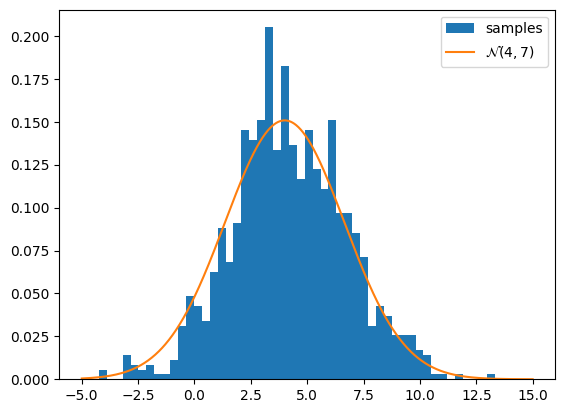

In [8]:
g = Gaussian(jnp.array([4]), jnp.array([[7]]))
KEY, g_key = random.split(KEY, 2)

g_samples = g.sample(sample_size = 1000, key = g_key)

x_axis = jnp.linspace(-5, 15, 1000).reshape(-1, 1)
pdf = g.pdf(x_axis)

plt.hist(g_samples, density = True, label = 'samples', bins = 50)
plt.plot(x_axis, pdf, label = r'$\mathcal{N}(4, 7)$')
plt.legend()

Now let us sample from our $X$.

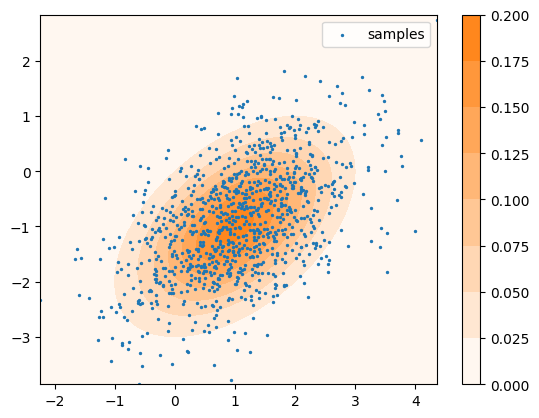

In [9]:
import matplotlib

cmap = matplotlib.colors.LinearSegmentedColormap.from_list(
    "owb", [(1, 1, 1), (255/255, 127/255, 14/255)], N = 1024
)

key, X_key = random.split(KEY, 2)
X_samples = X.sample(sample_size = 1000, key = X_key)

X1, X2 = jnp.meshgrid(jnp.arange(X_samples[:, 0].min(), X_samples[:, 0].max() + 0.1, 0.1), 
                      jnp.arange(X_samples[:, 1].min(), X_samples[:, 1].max() + 0.1, 0.1))
X_grid = jnp.stack((X1.flatten(), X2.flatten()), axis = 1)
Z = X.pdf(X_grid).reshape(X1.shape)

fig, ax = plt.subplots()
contour = ax.contourf(
    X1, X2, Z, cmap = cmap
)
ax.scatter(X_samples[:, 0], X_samples[:, 1], s = 2, label = "samples")
cb = fig.colorbar(ax = ax, mappable = contour)
ax.legend()

There will be more on sampling techniques in [Sampling notebook](<./9. Sampling.ipynb>).

# Precision and Precision-Weighted Mean

Let us introduce another useful quantity: **precision**. In one dimension, precision is the inverse of variance:
$$ \lambda = \sigma^{-2} $$
So, the greater the variance is, the lower is the precision. Geometrically speaking, higher precision results in a distribution more concentrated near its mean. It can be clearly seen on a 1D example.

Text(0.5, 0, '$x$')

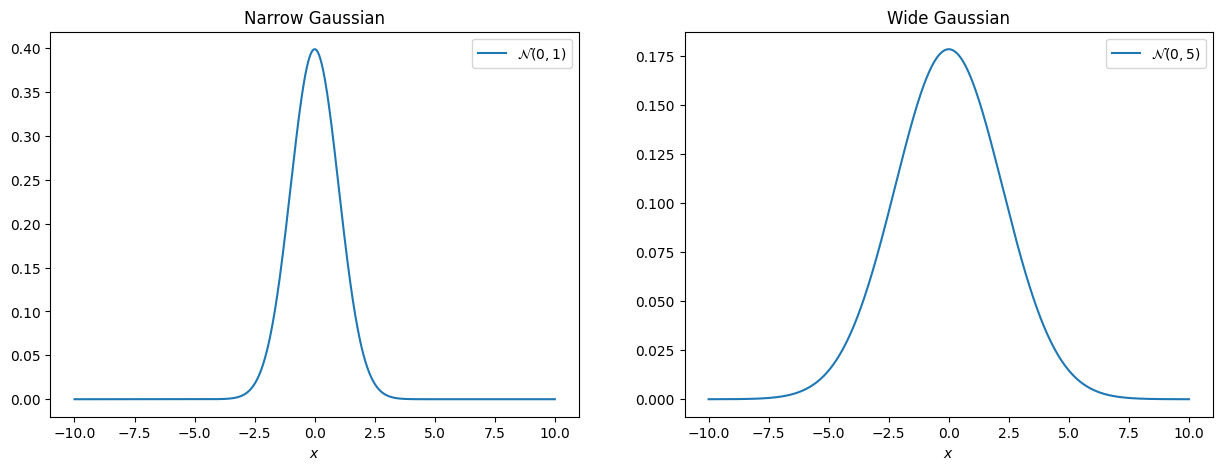

In [10]:
fig, axes = plt.subplots(1, 2, figsize = (15, 5))

g1 = Gaussian(jnp.array([0]), jnp.array([[1]]))
g2 = Gaussian(jnp.array([0]), jnp.array([[5]]))

x_axis = jnp.linspace(-10, 10, 1000).reshape(-1, 1)
pdf1 = g1.pdf(x_axis)
pdf2 = g2.pdf(x_axis)

axes[0].plot(x_axis, pdf1, label = r'$\mathcal{N}(0, 1)$')
axes[0].set_title("Narrow Gaussian")
axes[0].legend()
axes[0].set_xlabel(r"$x$")

axes[1].plot(x_axis, pdf2, label = r'$\mathcal{N}(0, 5)$')
axes[1].set_title("Wide Gaussian")
axes[1].legend()
axes[1].set_xlabel(r"$x$")

In the example above we can calculate the precisions as:
$$ \lambda_1 = \sigma_1^{-2} = \frac{1}{1} = 1 $$
$$ \lambda_2 = \sigma_2^{-2} = \frac{1}{5} = 0.2 $$

It was a simple 1D example, but the idea can be extended to a covariance matrix of any dimension using the following:
$$ \Lambda = \Sigma^{-1} $$
So, the precision of our $X$ defined before is:
$$ \Lambda = \begin{bmatrix} 1 & 0.5 \\ 0.5 & 1 \end{bmatrix}^{-1} = \begin{bmatrix} \frac{4}{3} & -\frac{2}{3} \\ -\frac{2}{3} & \frac{4}{3} \end{bmatrix} $$
In the Gaussian class it can be accessed using `X.precision` function. It is implemented using the Singular Value Decomposition (SVD) for better numerical computations. Let us consider some symmetric positive definite matrix $A$ and decompose it as:
$$ A = U \Sigma V^T $$
where $\Sigma$ is a diagonal matrix consisting of singular values of $A$ as entries. Then, the inverse of $A$ can be written as:
$$ A^{-1} = \left( U \Sigma V^T \right)^{-1} = V \Sigma^{-1} U^T = U \Sigma^{-1} V^T $$

* the second equality is due to orthogonality of $V$ and $U$
* the third equality is since $V = U$ for positive definite $A$. 
So the only thing we are left to do is to invert the singular values. Since $\Sigma$ is diagonal, its inverse is a diagonal matrix of the elementwise reciprocals of the singular values:
$$ \Sigma^{-1} = \begin{bmatrix} \sigma_1^2 & 0 & \dots & 0\\
0 & \sigma_2^2 & \dots & 0 \\
\vdots & \vdots & \ddots & \vdots \\
0 & 0 & \dots & \sigma_d^{2} \end{bmatrix}^{-1} = \begin{bmatrix} \sigma_1^{-2} & 0 & \dots & 0\\
0 & \sigma_2^{-2} & \dots & 0 \\
\vdots & \vdots & \ddots & \vdots \\
0 & 0 & \dots & \sigma_d^{-2} \end{bmatrix} $$

In [11]:
X.precision

Array([[ 1.33333333, -0.66666667],
       [-0.66666667,  1.33333333]], dtype=float64)

Another identity we will need is **mean-weighted precision**, defined as:
$$ \eta = \Lambda \mu $$
It will be used later when we will consider linear operations with Gaussians and Exponential Families.

Let us consider the Gaussian exponent:
$$ -\frac{1}{2} (x - \mu)^T \underbrace{\Sigma^{-1}}_{\Lambda} (x - \mu) $$
we can expand the quadratic as:
$$ -\frac{1}{2} x^T \Lambda x + x^T \underbrace{\Lambda \mu}_{\eta} - \frac{1}{2} \mu^T \Lambda \mu $$
So, Gaussian can be represented using $(\eta, \Lambda)$ instead of $(\mu, \Sigma)$.

In the dataclass, the mean-weighted precision was called `mp` (mean precision).

In [12]:
X.mp

Array([ 2., -2.], dtype=float64)

# Marginals

We can also access the marginals of the multivariate Gaussians using indexing. Let us consider our $X$:
$$ X = \begin{bmatrix} X_1 \\ X_2 \end{bmatrix} \sim \mathcal{N} \left( \begin{bmatrix} \mu_1 \\ \mu_2 \end{bmatrix}, \begin{bmatrix} \Sigma_{11} & \Sigma_{12} \\ \Sigma_{21} & \Sigma_{22} \end{bmatrix} \right) $$

Then we can access:
$$ X_1 \sim \mathcal{N}(\mu_1, \Sigma_{11}) $$

In [13]:
X[0]

Gaussian(mu=Array([1], dtype=int64), Sigma=Array([[1.]], dtype=float64))

In [14]:
X[1]

Gaussian(mu=Array([-1], dtype=int64), Sigma=Array([[1.]], dtype=float64))

# Operations on Gaussians

A very useful property of Gaussians is that we can apply some operations to them and the result will stay as Gaussian. In this section we will consider such operations as:

* Addition of Gaussians
* Multiplication by Constant
* Linear Transformation
* Multiplication of Gaussians
* Conditioning on Gaussian

all of which will be eventually used later in the project

## Addition of Gaussians

Two **independent** Gaussians can be added to form another Gaussian. Let $X$ and $Y$ be independent multivariate Gaussians:
$$ X \sim \mathcal{N}(\mu_X, \Sigma_X), \quad Y \sim \mathcal{N}(\mu_Y, \Sigma_Y) $$

Then, their addition is:
$$ Z = X + Y \sim \mathcal{N}(\mu_X + \mu_Y, \Sigma_X + \Sigma_Y) $$

In [15]:
Y = Gaussian(jnp.array([1, 3]), jnp.array([[1, 0], [0, 1]]))

X + Y

Gaussian(mu=Array([2, 2], dtype=int64), Sigma=Array([[2. , 0.5],
       [0.5, 2. ]], dtype=float64))

## Multiplication by Constant

A multivariate Gaussian can be also multiplied by a constant. Let $c \in \mathbb{R}$, then:
$$ cX \sim \mathcal{N}(c\mu, c^2\Sigma) $$
It can be accessed using reverse multiplication (`__rmul__`) or multiplication operator(`*`).

In [16]:
c = 4.7

X.__rmul__(c)

Gaussian(mu=Array([ 4.7, -4.7], dtype=float64, weak_type=True), Sigma=Array([[22.09 , 11.045],
       [11.045, 22.09 ]], dtype=float64))

In [17]:
c * X

Gaussian(mu=Array([ 4.7, -4.7], dtype=float64, weak_type=True), Sigma=Array([[22.09 , 11.045],
       [11.045, 22.09 ]], dtype=float64))

## Linear Transformation

We will need to apply linear transformations on multivariate Gaussians. Suppose our transformation is:
$$ A \in \mathbb{R}^{d \times d} $$
and we want to apply it to our previously defined $X \sim \mathcal{N}(\mu, \Sigma)$.

Then, the resulting Gaussian is:
$$ AX \sim \mathcal{N} (A \mu, A \Sigma A^T) $$

Linear transformation can be called using reverse matrix multiplication `X.__rmatmul__(A)`

In [18]:
A = jnp.array([[1, 2], [3, 4]])

X.__rmatmul__(A)

Gaussian(mu=Array([-1, -1], dtype=int64), Sigma=Array([[ 7., 16.],
       [16., 37.]], dtype=float64))

Or, easier using matrix multiplication operator `@`.

In [19]:
A @ X

Gaussian(mu=Array([-1, -1], dtype=int64), Sigma=Array([[ 7., 16.],
       [16., 37.]], dtype=float64))

## Multiplication of Gaussians

Probably the most important property of Gaussians is that the multiplication of two Gaussians is also a Gaussian. It can be considered as **combining** information about the **same unknown value**. Let us say we want to estimate some unknown value $x$ and have two different estimators:

* First one says that $x \approx 10$
* Second one says that $x \approx 12$

Then, if we **combine** the information gained from two estimators, we get that $x$ is somewhere in-between 10 and 12. If we also consider how *confident* are our estimators, we can better estimate where exactly is $x$. Let us assume that:

* The first estimator is very confident that $x \approx 10$
* The second one is not confident that $x \approx 12$

in this case we can conclude that $x$ is somewhere in-between 10 and 12 being closer to 10 than to 12. So the resulting piece of information tell us, very confidently, that $x \approx 10.18$ (computations later). This is where we use our **precision**. Let us formulate this case more rigorously. Let:
$$ X \sim \mathcal{N}(10, 1), \quad Y \sim \mathcal{N}(12, 10) $$
be our two pieces of information we are using to estimate our unknown $x$. Then, the precisions of our estimators are:
$$ \lambda_1 = \frac{1}{\sigma_1^2} = 1, \quad \lambda_2 = \frac{1}{\sigma_2^2} = 0.1 $$
by the definition discussed above.

Since we are becoming more confident in our estimation, the precision of our new piece of information $Z$ should be higher than both of the initial precisions:
$$ \lambda_3 = \lambda_1 + \lambda_2 = 1.1 $$

The combined mean will then be the weighted average between two initial means:
$$ \mu_3 = \frac{\lambda_1 \mu_1 + \lambda_2 \mu_2}{\lambda_1 + \lambda_2} = \frac{1 \times 10 + 0.1 \times 12}{1 + 0.1} = \frac{112}{11} $$

So, the new information we obtained about $x$ is that:
$$ p_X(x) p_Y(x) \propto \mathcal{N} \left(x; \frac{112}{11}, \frac{10}{11} \right) $$
The variance was calculated using:
$$ \sigma^2 = \frac{1}{\lambda} = \frac{10}{11} $$

In general case, if we have:
$$ X \sim \mathcal{N}(\mu_X, \Sigma_X), \quad Y \sim \mathcal{N}(\mu_Y, \Sigma_Y) $$
Then, their multiplication is:
$$ p_X(x) p_Y(x) \propto \mathcal{N}(x; \mu_Z, \Sigma_Z) $$
where:

* $\Sigma_Z = \left( \Sigma_X^{-1} + \Sigma_Y^{-1} \right)^{-1}$
* $\mu_Z = \Sigma_Z \left( \Sigma_X^{-1} \mu_X + \Sigma_Y^{-1} \mu_Y \right)$

It is exactly the same as we have done above:
$$ \Lambda_Z = \Lambda_X + \Lambda_Y \Rightarrow \Sigma_Z = \Lambda_Z^{-1} = \left( \Sigma_X^{-1} + \Sigma_Y^{-1} \right)^{-1} $$
and
$$ \mu_Z = \Lambda_Z^{-1} (\Lambda_X \mu_X + \Lambda_Y \mu_Y) = \Sigma_Z (\Sigma_X^{-1} \mu_X + \Sigma_Y^{-1} \mu_Y) $$

<div style="
    padding: 12px 16px;
    background-color: #e9f3fa;
    border-left: 5px solid #2196f3;
    border-radius: 6px;
">

<strong>Note:</strong> Here we do not claim that $p_Z$ is probability density, since we do not normalize it after the operation.

However, if we find the normalization constant
$$K = \int_{-\infty}^{\infty} p_Z(x)\,dx,$$
and divide the resulting density by that constant,
$$\tilde p_Z(x) = \frac{p_Z(x)}{K},$$
we obtain a valid Gaussian distribution. This normalization is unnecessary when it is enough to know that $Z$ is Gaussian and $p_Z$ is a Gaussian density up to normalization. This is why we use proportionality rather than equality in the formulae above.

</div>

In [20]:
X * Y

Gaussian(mu=Array([1.53333333, 0.86666667], dtype=float64), Sigma=Array([[0.46666667, 0.13333333],
       [0.13333333, 0.46666667]], dtype=float64))

In [21]:
Y * X

Gaussian(mu=Array([1.53333333, 0.86666667], dtype=float64), Sigma=Array([[0.46666667, 0.13333333],
       [0.13333333, 0.46666667]], dtype=float64))

Note that the multiplication of Gaussians is symmetric, it can be seen using the intuition above where we considered two estimators. We do not care much about the order of the information gain from the estimators.

# Conditioning on Gaussian

## Univariate Example

The last property that we will consider today is that we can condition one Gaussian distribution over another one and the result will also have a Gaussian shape. Let us consider the example above, but from a different perspective: let us have a number we want to estimate, some prior knowledge about it, and some noisy measurement tool.

Suppose we want to estimate a scalar $x$ and we assume that we are quite confident that it is somewhere around 10, let us call that assumption a **prior** knowledge about $x$:
$$ X \sim \mathcal{N}(10, 1) $$
and let the measurement tool's noise can be modelled as:
$$ \varepsilon \sim \mathcal{N}(0, 10), \quad \varepsilon \perp X $$
Now, the outcome of our measurement can be modelled as:
$$ Y = X + \varepsilon \sim \mathcal{N}(10, 11) $$
the distribution is so since $X$ and $\varepsilon$ are independent.

Let us say that we have observed a single value $y = 12$. Then, we can, using the above assumptions, model the likelihood of observing $y=12$ as:
$$ Y \mid X=x \sim \mathcal{N}(x, 10) \Rightarrow p(y \mid x) = L_{Y \mid X} (12 \mid x) = \mathcal{N}(12; x, 10) $$

If we write down the exponential part of the likelihood, we can see:
$$ -\frac{(12 - x)^2}{2 \times 10} $$
but here we can see that
$$ (12 - x)^2 = (x - 12)^2 $$
so, we can revert the likelihood without losing the rigour:
$$ p(y \mid x) = \mathcal{N}(12; x, 10) = \mathcal{N}(x; 12, 10) $$

Now when we know the **prior** and the **likelihood**, we can use Bayes' theorem to calculate the posterior:
$$ p(x \mid y) \propto p(y \mid x) p(x) = \mathcal{N}(x; 12, 10) \mathcal{N}(x; 10, 1) $$
which is the multiplication of Gaussians that we have considered in the previous subsection.

Since the distributions are the same, we already know that the posterior is:
$$ X \mid Y = 12 \sim \mathcal{N} \left( \frac{112}{11}, \frac{10}{11} \right) $$

## Multivariate Gaussian Example with One Observation

### Framework

In general, we can have observational model of another form. Here we can use the linear transformation covered before. Let us have a linear regression model with unknown regression weights vector $x \in \mathbb{R}^{d}$. For now let us assume we have only one observation of feature vector $a$ and target value $y$. Our prior knowledge about the regression weights is
$$ X \sim \mathcal{N}(\mu, \Sigma), \quad \mu \in \mathbb{R}^d, \Sigma \in \mathbb{R}^{d \times d} $$

The observational model we have is, then:
$$ Y = a^T X + \varepsilon, \quad \varepsilon \sim \mathcal{N}(0, r), \varepsilon \perp X $$

The likelihood of observing $y$ from our model is:
$$ p_{Y \mid X} (y | x) = \mathcal{N}(y; a^Tx, r) $$

Similarly to the univariate example, the posterior is:
$$ p(x \mid y) \propto p(y \mid x) p(x) $$
but in this case we cant switch the variables in the likelihood as easy. The math of the calculation of the posterior will be considered in the next sections.

Here is the general framework for the Conditioning on Multivariate Gaussian

### Preliminaries

Let us calculate the mean and the variance of $Y$ and covariance between $X$ and $Y$. They will be needed to obtain the posterior mean and covariance.

* Mean of $Y$:
$$ \begin{aligned} 
\mathbb{E} [Y] &= \mathbb{E} [a^T X + \varepsilon] \\
&= a^T \mathbb{E} [X] + \mathbb{E} [\varepsilon] \\
&= a^T \mu
\end{aligned}$$
* Variance of $Y$:
$$  \begin{aligned}
\text{Var} (Y) &= \text{Var} (a^T X + \varepsilon) \\
&= a^T \text{Var} (X) a + \text{Var} (\varepsilon) + 2 \underbrace{\text{Cov} (a^T X, \varepsilon)}_{=0} \\
&= a^T \Sigma a + r =: S
\end{aligned} $$
* Covariance of $X$ and $Y$:
$$ \begin{aligned}
\text{Cov} (X, Y) &= \text{Cov}(X, a^TX + \varepsilon) \\
&= \text{Cov}(X, a^TX) + \text{Cov}(X, \varepsilon) \\
&= \Sigma a
\end{aligned} $$

So, the joint distribution of $X$ and $Y$ is:
$$ \begin{bmatrix} X \\ Y \end{bmatrix} \sim \mathcal{N} \left( \begin{bmatrix} \mu \\ a^T \mu \end{bmatrix}, \begin{bmatrix} \Sigma & \Sigma a \\ a^T \Sigma & S \end{bmatrix} \right) $$

### Mean of Posterior

To calculate the mean of the posterior we decompose $X$ as:
$$ \begin{aligned}
X &= \underbrace{X - (\mu + K(Y - a^T \mu))}_{=: R} + (\mu + K(Y - a^T \mu)) \\ 
&= \mu + K(Y - a^T \mu) + R
\end{aligned} $$
where:

* $R$ is a $d$-variate Gaussian
* $K \in \mathbb{R}^{d}$ is an arbitrary vector

At this point we are free to choose $K$ so that $R$ and $Y$ are uncorrelated:
$$ \text{Cov}(R, Y) = \Sigma a - KS = 0 \Rightarrow K = \Sigma a S^{-1} $$
it is called **Kalman gain**.

Since $R$ and $Y$ are jointly Gaussian, zero covariance means independence.

So, after observing $Y=y$, we have:
$$ X = \mu + \Sigma a S^{-1} (y - a^T \mu) + R $$
since $R$ has mean of 0:
$$ \mu_{\text{post}} = \mathbb{E}[X \mid Y = y] = \mathbb{E} [\mu + \Sigma a S^{-1} (y - a^T \mu) + R] = \mu + \Sigma a S^{-1} (y - a^T \mu) $$
So, the posterior mean is:
$$ \boxed{\mu_{\text{post}} = \mu + \Sigma a S^{-1} (y - a^T \mu)} $$

### Covariance of Posterior

Since we have fixed the observation as $Y = y$, the only randomness is coming from $R$, then:
$$ \Sigma_{\text{post}} = \text{Var}(R) $$

Let us compute it:
$$ \begin{aligned}
\Sigma_{\text{post}} &= \text{Var}(R) \\
&= \text{Var}((X - \mu) - K(Y - a^T \mu)) \\
&= \Sigma - K \underbrace{\text{Cov}(Y, X)}_{a^T \Sigma^T} - \underbrace{\text{Cov}(X, Y)}_{\Sigma a} K^T + KSK^T \\
&= \Sigma - (\Sigma a S^{-1}) a^T \Sigma^T - \Sigma a (S^{-1} a^T \Sigma^T) + (\Sigma a S^{-1}) S (S^{-1} a^T \Sigma^T) \\
&= \Sigma - \Sigma a S^{-1} a^T \Sigma^T - \Sigma a S^{-1} a^T \Sigma^T + \Sigma a S^{-1} a^T \Sigma^T \\
&= \Sigma - \Sigma a S^{-1} a^T \Sigma
\end{aligned}$$

Since covariance is symmetric, we have
$$ \Sigma^T = \Sigma $$

So we are left with
$$ \boxed{\Sigma_{\text{post}} = \Sigma - \Sigma a S^{-1} a^T \Sigma} $$

### Results

So, the posterior update for the Multivariate Gaussian Conditioning with Single Observation is:
$$ S = a^T \Sigma a + r $$
$$ \mu_{\text{post}} = \mu + \Sigma a S^{-1} (y - a^T \mu) $$
$$ \Sigma_{\text{post}} = \Sigma - \Sigma a S^{-1} a^T \Sigma $$

## Multivariate Gaussian Example with Multiple Observations

The results from the previous section can be easily extended into a framework where several observations come at the same time. Then, the framework stays similar with:

* **Prior**: $X \sim \mathcal{N} (\mu, \Sigma)$
* **Observation features**: $A \in \mathbb{R}^{n \times d}$
* **Observation targets**: $y \in \mathbb{R}^{n}$
* **Observation noise**: $\Epsilon \sim \mathcal{N}(0, R)$, $\Epsilon \perp X$
* **Observational model**: $Y = AX + \Epsilon$
* **Likelihood**: $Y \mid X = x \sim \mathcal{N}(Ax, R)$
* **Posterior**: $X \mid Y = y \sim \mathcal{N}(\mu_{\text{post}}, \Sigma_{\text{post}})$

Using similar computations we can obtain:
$$ S = A \Sigma A^T + R $$
$$ \mu_{\text{post}} = \mu + \Sigma A^T S^{-1} (y - A\mu) $$
$$ \Sigma_{\text{post}} = \Sigma - \Sigma A^T S^{-1} A \Sigma $$

The usage of the findings will be discussed in [Regression notebook](<./2. Bayesian Regression.ipynb>)